# **4-펭귄 종을 분류할 수 있는 방법은 무엇일까**

#### **데이터 준비 : 데이터셋 수집**

남극 팔머 기지 펭귄 데이터(adelie, gentoo, chinstrap)

https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?select=penguins_size.csv

## **[1] 데이터 불러오기**

1.1 파일 업로드하기

In [1]:
from google.colab import files
uploaded = files.upload()

1.2 데이터프레임 생성하기

In [2]:
import pandas as pd
df = pd.read_csv('/content/penguins_size.csv')
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## **[2] 탐색적 데이터 분석 및 전처리하기**

2.1 전체적인 데이터 살펴보기

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


2.2 결측치 처리하기

In [4]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [5]:
df.dropna(inplace=True)
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


2.3 펭귄 성별 고유값 구하기

In [6]:
df['sex'].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

2.4 펭귄 성별 중 잘못된 값 삭제하기

In [7]:
df[df['sex'] == '.']

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [8]:
df.drop(axis=0, inplace=True, index=df[df['sex'] == '.'].index)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   culmen_length_mm   333 non-null    float64
 3   culmen_depth_mm    333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


2.5 펭귄 종별 개수 구하기

In [9]:
df['species'].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


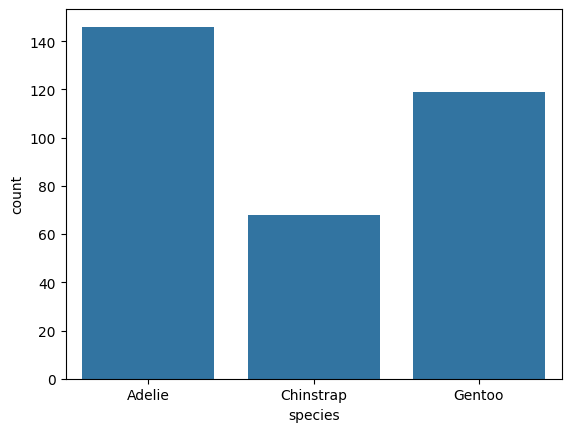

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='species', data=df)
plt.show()

2.6 펭귄 종별 날개 길이를 박스 플롯으로 시각화하기

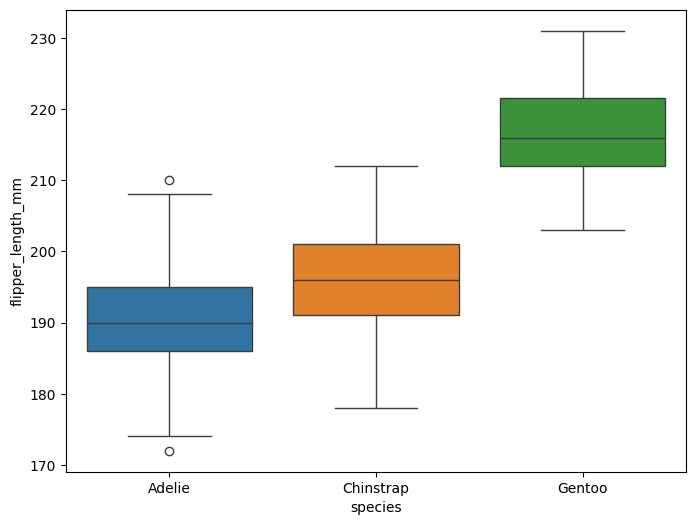

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='species', y='flipper_length_mm', hue='species', data=df)
plt.show()

2.7 특징값을 산점도로 시각화하기

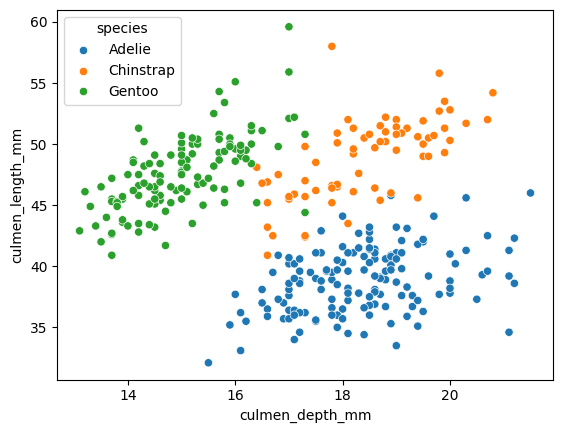

In [12]:
sns.scatterplot(x='culmen_depth_mm', y='culmen_length_mm', hue='species', data=df)
plt.show()

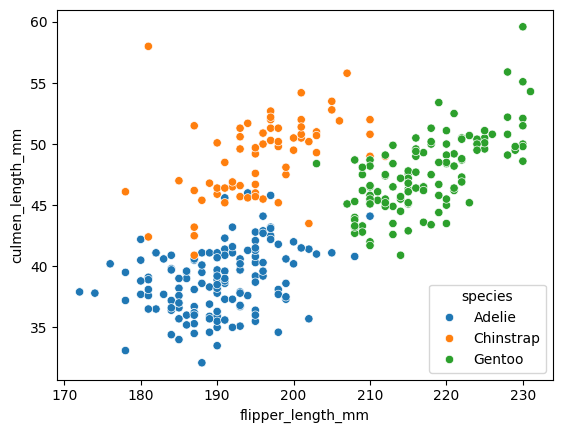

In [13]:
sns.scatterplot(x='flipper_length_mm', y='culmen_length_mm', hue='species', data=df)
plt.show()

2.8 특징과 타깃 선정하기

In [14]:
df1 = df[['culmen_depth_mm', 'culmen_length_mm', 'flipper_length_mm', 'species']]
df1.head()

,culmen_depth_mm,culmen_length_mm,flipper_length_mm,species
0,18.7,39.1,181.0,Adelie
1,17.4,39.5,186.0,Adelie
2,18.0,40.3,195.0,Adelie
4,19.3,36.7,193.0,Adelie
5,20.6,39.3,190.0,Adelie


In [15]:
dataset = df1.values
X = dataset[:, :-1]
y = dataset[:, -1]

In [16]:
print(f"특징 모양: {X.shape}")
print(f"타깃 모양: {y.shape}")

특징 모양: (333, 3)
타깃 모양: (333,)


2.9 훈련 데이터, 테스트 데이터 분할하기

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0 )

In [18]:
print("훈련 데이터: ", X_train.shape, y_train.shape)
print("테스트 데이터: ", X_test.shape, y_test.shape)

훈련 데이터:  (233, 3) (233,)
테스트 데이터:  (100, 3) (100,)


2.10. 데이터 정규화하기

In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"원본 훈련: {X_train[0]}, 스케일링된 훈련 데이터: {X_train_scaled[0]}")
print(f"원본 테스트: {X_test[0]}, 스케일링된 테스트 데이터: {X_test_scaled[0]}")

원본 훈련: [13.2 46.1 211.0], 스케일링된 훈련 데이터: [0.01234568 0.49056604 0.64912281]
원본 테스트: [20.3 41.3 194.0], 스케일링된 테스트 데이터: [0.88888889 0.30943396 0.35087719]


## **[3] 모델 생성하기**

3.1 최근접 이웃 알고리즘으로 학습하기

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [21]:
print("훈련 데이터 정확도 : ", knn.score(X_train_scaled, y_train))

훈련 데이터 정확도 :  0.9828326180257511


## **[4] 모델 평가 및 예측하기**

4.1 모델 평가하기

In [22]:
print("테스트 데이터 정확도: ", knn.score(X_test_scaled, y_test))

테스트 데이터 정확도:  0.97


4.2 최적의 k 구하기

In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
k_values = range(2, 11)
cv_scores = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=cv)
    cv_scores.append(scores.mean())
    print(f"k: {k:2d}, CV 평균 정확도: {scores.mean()*100:.2f}%")

optimal_k = k_values[cv_scores.index(max(cv_scores))]
print(f"최적 k 값: {optimal_k}")

k:  2, CV 평균 정확도: 97.44%
k:  3, CV 평균 정확도: 97.86%
k:  4, CV 평균 정확도: 97.86%
k:  5, CV 평균 정확도: 97.86%
k:  6, CV 평균 정확도: 97.86%
k:  7, CV 평균 정확도: 97.86%
k:  8, CV 평균 정확도: 98.30%
k:  9, CV 평균 정확도: 97.86%
k: 10, CV 평균 정확도: 97.86%
최적 k 값: 8


4.3 테스트 데이터 예측하기

In [24]:
predictions = knn.predict(X_test_scaled)

In [25]:
print(predictions[:5])
print(y_test[:5])

['Adelie' 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie']
['Adelie' 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie']


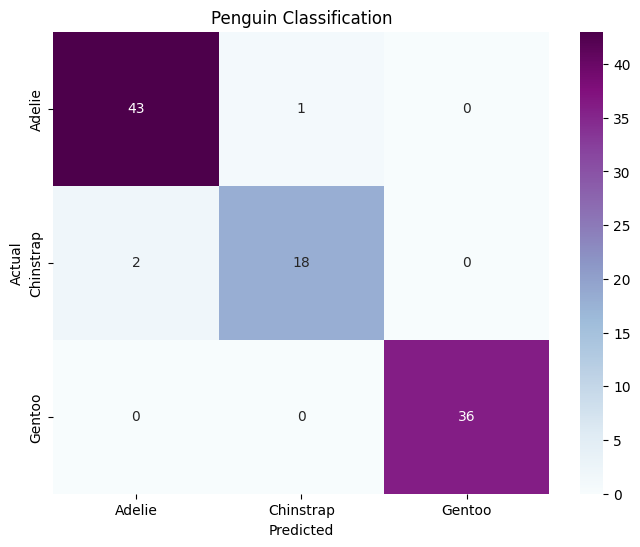

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
plt.figure(figsize=(8, 6))

conf = confusion_matrix(y_test, predictions)
class_names = ['Adelie', 'Chinstrap', 'Gentoo']
sns.heatmap(conf, annot=True, fmt='d', cmap="BuPu",
            xticklabels=class_names, yticklabels=class_names)

plt.title('Penguin Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **[5] 모델 활용하기**

5.1 새로운 데이터프레임 생성하기

In [27]:
from google.colab import files
uploaded = files.upload()


In [28]:
df_new = pd.read_csv('/content/penguin_new.csv')
df_new.head()

,culmen_depth_mm,culmen_length_mm,flipper_length_mm
0,18.7,39.1,181
1,18.5,46.9,200
2,14.5,50.0,250


5.2 데이터 정규화하기

In [29]:
dataset_new = df_new.values
new_scaled = scaler.transform(dataset_new)

5.3 새로운 데이터 예측하기

In [30]:
print(knn.predict(new_scaled))

['Adelie' 'Chinstrap' 'Gentoo']
